In [24]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline
import plotly.express as px 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [25]:
url = "https://raw.githubusercontent.com/MSalah-Data/Python-Projects/refs/heads/main/Anime%20Analysis_Python%20Project/anime.csv"
df = pd.read_csv(url)
pd.set_option("display.max_columns", None )
df.head(5)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [26]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


(12294, 7)

In [27]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [28]:
df[df['rating'] <0]

,anime_id,name,genre,type,episodes,rating,members


In [29]:
df['anime_id'].nunique()

12294

In [30]:
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12017 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12017 non-null  int64  
 1   name      12017 non-null  object 
 2   genre     12017 non-null  object 
 3   type      12017 non-null  object 
 4   episodes  12017 non-null  object 
 5   rating    12017 non-null  float64
 6   members   12017 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 751.1+ KB


In [32]:
df.sample(10)

,anime_id,name,genre,type,episodes,rating,members
3357,1024,Weiß Kreuz OVA,"Action, Drama",OVA,2,7.02,4296
7373,18425,Ikeike! Momon-chan Specials,Comedy,Special,3,5.49,321
9381,23597,Legend of Basara: Shinbashi Theater,Comedy,Special,1,6.31,163
5892,9598,Haiyoru! Nyaruani: Remember My Love(craft-sensei),"Comedy, Sci-Fi",TV,11,6.32,17934
9260,18301,Kkureogi Balmyeongwang,"Action, Mecha, Sci-Fi, Shounen",Movie,1,3.50,61
11795,3706,Seikoujo: Haitoku no Biden Dorei,Hentai,OVA,2,6.08,2038
5943,2019,DNA Sights 999.9,"Action, Adventure, Drama, Sci-Fi",OVA,1,6.30,1048
5073,29419,Pokemon XY: New Year&#039;s Eve 2014 Super Meg...,"Action, Adventure, Comedy, Fantasy, Kids",Special,1,6.56,1358
6292,19769,Mahou Sensou,"Action, Fantasy, Magic",TV,12,6.18,104192
11571,9467,Kanojo ga Mimai ni Konai Wake,"Drama, Hentai",OVA,3,6.41,2704


In [33]:
df['name'] = df['name'].str.replace('&quot;', '"', regex=False)
df['name'] = df['name'].str.replace('&amp;', '&', regex=False)

In [34]:
df.sample(5)

,anime_id,name,genre,type,episodes,rating,members
1534,2954,Maria-sama ga Miteru 3rd Specials,Comedy,Special,5,7.51,5072
1660,18229,Gatchaman Crowds,"Adventure, Sci-Fi",TV,12,7.47,107513
5155,9799,Shin-Men,"Action, Comedy, Kids",TV,13,6.54,479
1267,9930,Snow Halation,Music,Music,1,7.61,8731
9484,9856,Manga Nihon Emaki,Historical,TV,46,6.17,122


In [35]:
top10 = df.sort_values(by='members', ascending=False).head(10)
top10[['name', 'members']]

,name,members
40,Death Note,1013917
86,Shingeki no Kyojin,896229
804,Sword Art Online,893100
1,Fullmetal Alchemist: Brotherhood,793665
159,Angel Beats!,717796
19,Code Geass: Hangyaku no Lelouch,715151
841,Naruto,683297
3,Steins;Gate,673572
445,Mirai Nikki (TV),657190
131,Toradora!,633817


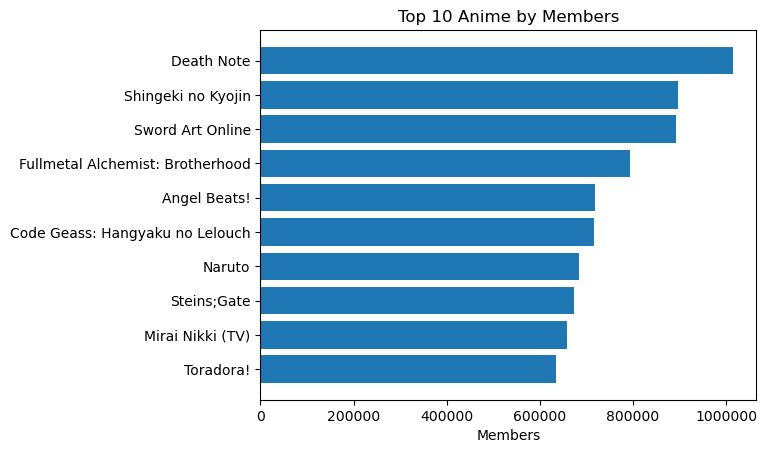

In [36]:
plt.barh(top10['name'], top10['members'])
plt.gca().invert_yaxis()
plt.xlabel('Members')
plt.title('Top 10 Anime by Members')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

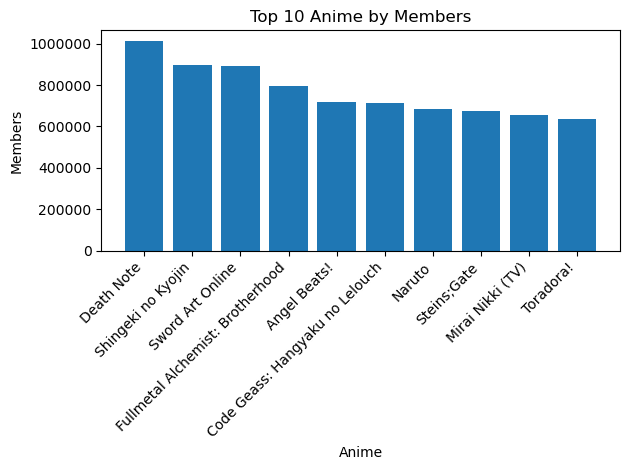

In [37]:
plt.figure()
plt.bar(top10['name'], top10['members'])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Anime')
plt.ylabel('Members')
plt.title('Top 10 Anime by Members')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [38]:
type_counts = df['type'].value_counts()

type_counts

type
TV         3668
OVA        3284
Movie      2259
Special    1670
ONA         648
Music       488
Name: count, dtype: int64

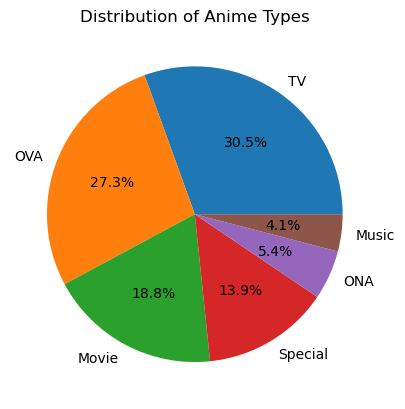

In [39]:
plt.figure()
type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distribution of Anime Types')
plt.show()

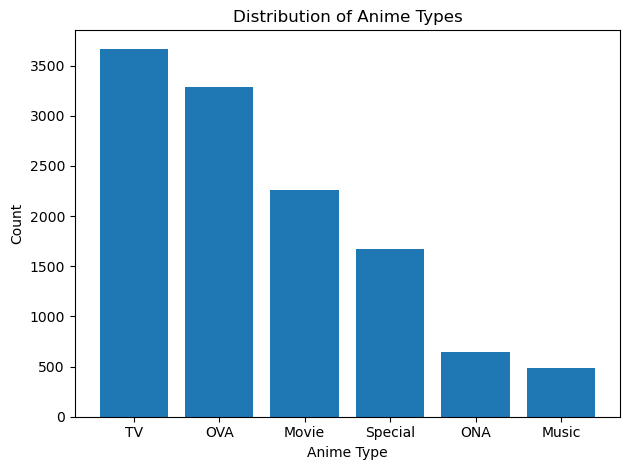

In [40]:
plt.figure()
plt.bar(type_counts.index, type_counts.values)

plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.title('Distribution of Anime Types')

plt.tight_layout()
plt.show()

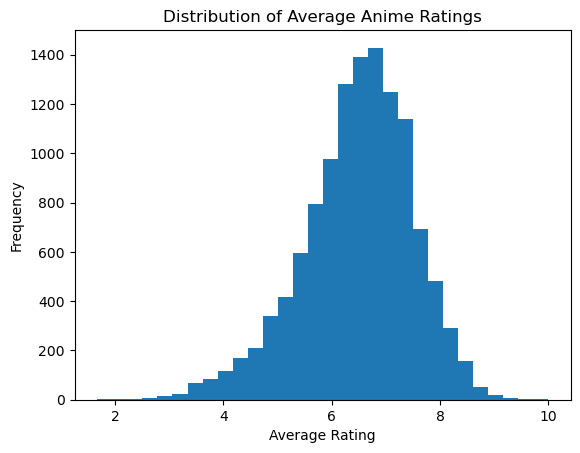

In [41]:
plt.figure()
plt.hist(df['rating'], bins=30)

plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Average Anime Ratings')

plt.show()

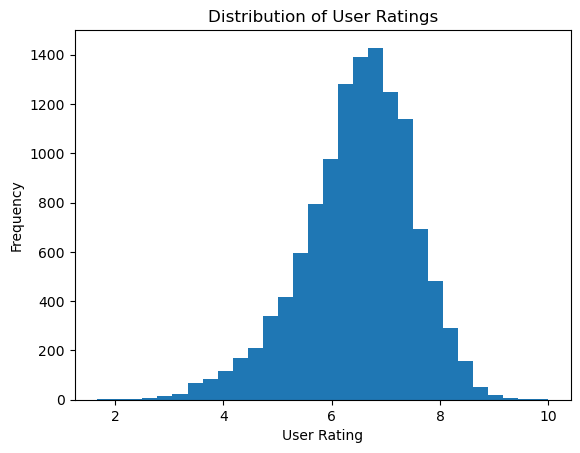

In [42]:
plt.figure()
plt.hist(df['rating'], bins=30)

plt.xlabel('User Rating')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')

plt.show()

In [43]:
#pip install wordcloud
from wordcloud import WordCloud
name_txt = " ".join(df['name'])
wc_pic = WordCloud( width = 400 , height = 400 , background_color = 'white' ).generate(name_txt)

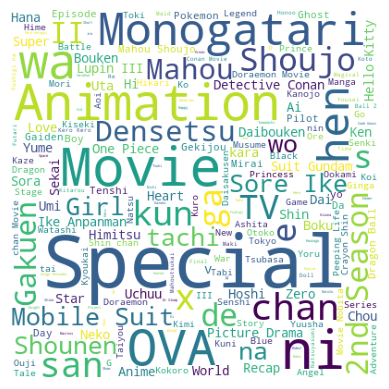

In [44]:
plt.imshow(wc_pic)
plt.axis('off')
plt.show()

In [45]:
#pip install ydata_profiling 
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/7 [00:00<?, ?it/s]
%|█▍        | 1/7 [00:00<00:00,  7.10it/s]
100%|██████████| 7/7 [00:00<00:00, 21.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
num_columns = [ 'episodes'  , 'members' ]

In [52]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

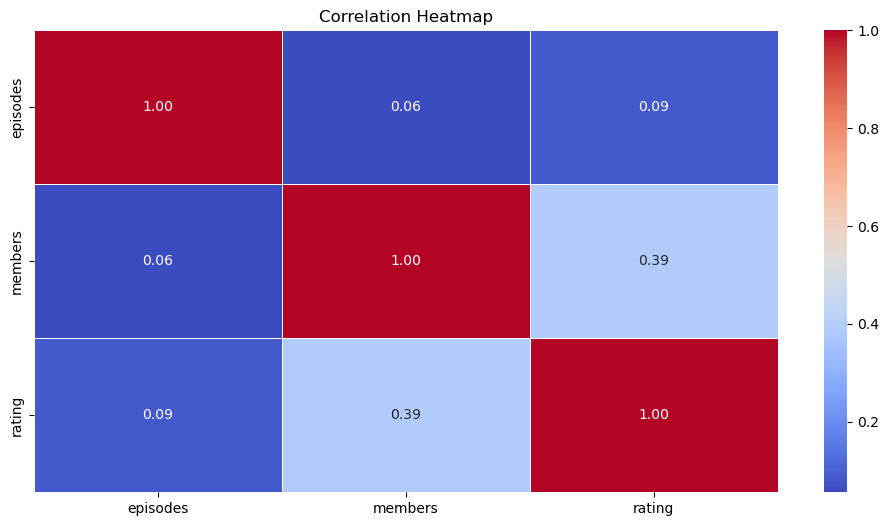

In [53]:
plt.figure(figsize=(12,6))
sns.heatmap(
    df[num_columns + ['rating']].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()